
# AIMLCZG546 - Software Engineering for Machine Learning
## Assignment I: ML-Based Product Recommendation for E-commerce

**Group:** G049

**Patterns implemented:** Microservices and CQRS

**Submission deadline:** 7 July 2026 (per final faculty clarification)

| Sl. | BITS ID | Name | Contribution | Percentage |
|---:|---|---|---|---:|
| 1 | TO_FILL | TO_FILL | Problem statement, requirements, measurable goals, and quality requirements | 25% |
| 2 | TO_FILL | TO_FILL | GR4ML Business, Analytics Design, and Data Preparation views | 25% |
| 3 | TO_FILL | TO_FILL | Microservices and CQRS architecture design and justification | 25% |
| 4 | TO_FILL | TO_FILL | ML implementation, tests, execution evidence, and report integration | 25% |

> Replace every `TO_FILL` value in `submission_details.json` and regenerate this
> notebook before portal upload.



## 1. Problem statement and measurable goal

Given implicit user feedback (views, clicks, carts, and purchases), rank unseen
catalogue products for each shopper. The primary offline goal is Precision@5;
supporting goals are Recall@5, Hit Rate@5, catalogue coverage, and a low-latency
read path.

This notebook executes the complete ML lifecycle: loading, schema validation,
deduplication, action weighting, matrix construction, leakage-safe evaluation,
item-item cosine-similarity training, artifact persistence, and inference.



## 2. Requirements engineering and goal alignment

Traditional software is usually deterministic, whereas an ML system is
probabilistic and depends on learned data patterns. Our requirements therefore
cover data quality and availability, behavior under uncertainty, reproducible
training, model updates, and continuous evaluation.

| Goal level | Goal in this application | Measure |
|---|---|---|
| Organizational | Increase revenue per shopping session | CTR uplift and average order value |
| Product | Show a useful personalized product block | Usage and response latency |
| User | Find interesting products quickly | Top-5 hit rate and user feedback |
| Model | Rank relevant unseen products | Precision@5, Recall@5, Coverage@5 |

The offline targets are Precision@5 >= 0.30, Recall@5 >= 0.70, and
Coverage@5 >= 0.80. The production targets are p95 serving latency below
200 ms and CTR uplift of at least 8%; these require load and A/B testing.


In [1]:

from pathlib import Path
import json
import numpy as np
import matplotlib.pyplot as plt

from ecom_ml.ml.data import (
    ACTION_WEIGHTS,
    generate_demo_interactions,
    load_interactions,
    prepare_interactions,
)
from ecom_ml.ml.pipeline import train_pipeline
from ecom_ml.ml.artifact import load_artifact

ROOT = Path.cwd()
DATA = ROOT / "data" / "interactions.csv"
ARTIFACTS = ROOT / "artifacts"

if not DATA.exists():
    generate_demo_interactions(DATA)

rows = load_interactions(DATA)
prepared = prepare_interactions(rows)
print("Action weights:", ACTION_WEIGHTS)
print("Raw events:", prepared.raw_event_count)
print("Unique events:", prepared.unique_event_count)
print("Users x items:", prepared.matrix.shape)
print("Matrix density:", round(np.count_nonzero(prepared.matrix) / prepared.matrix.size, 4))


Action weights: {'view': 1.0, 'click': 2.0, 'cart': 3.0, 'purchase': 5.0}
Raw events: 961
Unique events: 961
Users x items: (80, 60)
Matrix density: 0.2002


### ML code: loading and preprocessing

```python
"""Data loading and preprocessing for implicit-feedback recommendations."""

from __future__ import annotations

import csv
import threading
from dataclasses import dataclass
from datetime import UTC, datetime, timedelta
from pathlib import Path
from typing import Final

import numpy as np
from numpy.typing import NDArray

ACTION_WEIGHTS: Final[dict[str, float]] = {
    "view": 1.0,
    "click": 2.0,
    "cart": 3.0,
    "purchase": 5.0,
}
CSV_FIELDS: Final[tuple[str, ...]] = ("event_id", "timestamp", "user_id", "item_id", "action")
_WRITE_LOCK = threading.Lock()


@dataclass(frozen=True, slots=True)
class Interaction:
    """One raw storefront interaction."""

    event_id: str
    timestamp: str
    user_id: str
    item_id: str
    action: str

    def as_csv_row(self) -> dict[str, str]:
        return {
            "event_id": self.event_id,
            "timestamp": self.timestamp,
            "user_id": self.user_id,
            "item_id": self.item_id,
            "action": self.action,
        }


@dataclass(frozen=True, slots=True)
class PreparedInteractions:
    """Validated, weighted user-item matrix and its index labels."""

    users: tuple[str, ...]
    items: tuple[str, ...]
    matrix: NDArray[np.float64]
    raw_event_count: int
    unique_event_count: int


def generate_demo_interactions(
    path: Path,
    *,
    user_count: int = 80,
    item_count: int = 60,
    seed: int = 546,
) -> list[Interaction]:
    """Generate deterministic clustered shopping behavior and save it as CSV."""
    rng = np.random.default_rng(seed)
    users = [f"u{i:03d}" for i in range(1, user_count + 1)]
    items = [f"P{i:03d}" for i in range(1, item_count + 1)]
    cluster_count = 5
    cluster_size = item_count // cluster_count
    base_time = datetime(2026, 1, 1, 9, 0, tzinfo=UTC)
    events: list[Interaction] = []

    for user_index, user_id in enumerate(users):
        cluster = user_index % cluster_count
        core_start = cluster * cluster_size
        neighbor_start = ((cluster + 1) % cluster_count) * cluster_size
        core = np.arange(core_start, core_start + cluster_size)
        neighbor = np.arange(neighbor_start, neighbor_start + cluster_size)
        selected_core = rng.choice(core, size=min(10, len(core)), replace=False)
        selected_neighbor = rng.choice(neighbor, size=min(2, len(neighbor)), replace=False)

        for item_index in np.concatenate((selected_core, selected_neighbor)):
            action = str(
                rng.choice(
                    ["view", "click", "cart", "purchase"],
                    p=[0.30, 0.35, 0.22, 0.13],
                )
            )
            event_number = len(events) + 1
            timestamp = (base_time + timedelta(seconds=event_number * 17)).isoformat()
            events.append(
                Interaction(
                    event_id=f"evt-{event_number:05d}",
                    timestamp=timestamp,
                    user_id=user_id,
                    item_id=items[int(item_index)],
                    action=action,
                )
            )

    path.parent.mkdir(parents=True, exist_ok=True)
    with path.open("w", encoding="utf-8", newline="") as handle:
        writer = csv.DictWriter(handle, fieldnames=list(CSV_FIELDS))
        writer.writeheader()
        writer.writerows(event.as_csv_row() for event in events)
    return events


def load_interactions(path: Path) -> list[Interaction]:
    """Read raw events from CSV and validate the required schema."""
    if not path.exists():
        raise FileNotFoundError(f"interaction dataset not found: {path}")

    with path.open(encoding="utf-8", newline="") as handle:
        reader = csv.DictReader(handle)
        if reader.fieldnames is None or not set(CSV_FIELDS).issubset(reader.fieldnames):
            raise ValueError(f"dataset must contain columns: {', '.join(CSV_FIELDS)}")
        rows = [
            Interaction(
                event_id=(row["event_id"] or "").strip(),
                timestamp=(row["timestamp"] or "").strip(),
                user_id=(row["user_id"] or "").strip(),
                item_id=(row["item_id"] or "").strip(),
                action=(row["action"] or "").strip().lower(),
            )
            for row in reader
        ]
    if not rows:
        raise ValueError("interaction dataset is empty")
    return rows


def append_interaction(path: Path, interaction: Interaction) -> None:
    """Append one validated command to the raw interaction log."""
    validate_interaction(interaction)
    path.parent.mkdir(parents=True, exist_ok=True)
    with _WRITE_LOCK:
        needs_header = not path.exists() or path.stat().st_size == 0
        with path.open("a", encoding="utf-8", newline="") as handle:
            writer = csv.DictWriter(handle, fieldnames=list(CSV_FIELDS))
            if needs_header:
                writer.writeheader()
            writer.writerow(interaction.as_csv_row())


def validate_interaction(interaction: Interaction) -> None:
    """Validate fields used by both batch loading and command ingestion."""
    if not interaction.event_id:
        raise ValueError("event_id is required")
    if not interaction.user_id:
        raise ValueError("user_id is required")
    if not interaction.item_id:
        raise ValueError("item_id is required")
    if interaction.action not in ACTION_WEIGHTS:
        allowed = ", ".join(ACTION_WEIGHTS)
        raise ValueError(f"action must be one of: {allowed}")
    try:
        datetime.fromisoformat(interaction.timestamp)
    except ValueError as exc:
        raise ValueError("timestamp must be ISO-8601") from exc


def prepare_interactions(rows: list[Interaction]) -> PreparedInteractions:
    """Deduplicate, validate, weight, and aggregate raw events into a matrix."""
    unique: dict[str, Interaction] = {}
    for row in rows:
        validate_interaction(row)
        unique.setdefault(row.event_id, row)

    users = tuple(sorted({row.user_id for row in unique.values()}))
    items = tuple(sorted({row.item_id for row in unique.values()}))
    if not users or not items:
        raise ValueError("at least one user and item are required")

    user_index = {user_id: index for index, user_id in enumerate(users)}
    item_index = {item_id: index for index, item_id in enumerate(items)}
    matrix = np.zeros((len(users), len(items)), dtype=np.float64)
    for row in unique.values():
        matrix[user_index[row.user_id], item_index[row.item_id]] += ACTION_WEIGHTS[row.action]

    return PreparedInteractions(
        users=users,
        items=items,
        matrix=matrix,
        raw_event_count=len(rows),
        unique_event_count=len(unique),
    )

```

In [2]:

summary = train_pipeline(DATA, ARTIFACTS, k=5, holdout_per_user=2)
print(json.dumps(summary.as_dict(), indent=2))


[1/5] LOAD       /Users/sumanth/Library/CloudStorage/GoogleDrive-2025aa05544@wilp.bits-pilani.ac.in/My Drive/SEM2 ASSIGNMENT/SEML/seml-ecommerce-reco/data/interactions.csv


[2/5] PREPARE    validate, deduplicate, weight, aggregate


[3/5] EVALUATE   leave-2-out Precision@5


[4/5] TRAIN      fit item-item cosine similarity on all events


[5/5] PERSIST    /Users/sumanth/Library/CloudStorage/GoogleDrive-2025aa05544@wilp.bits-pilani.ac.in/My Drive/SEM2 ASSIGNMENT/SEML/seml-ecommerce-reco/artifacts


DONE version=c16386695e1a precision@5=0.3300 coverage@5=1.0000


{
  "model_type": "item-based-collaborative-filtering",
  "version": "c16386695e1a",
  "users": 80,
  "items": 60,
  "raw_events": 961,
  "unique_events": 961,
  "matrix_density": 0.2002,
  "metrics": {
    "precision_at_k": 0.33,
    "recall_at_k": 0.825,
    "hit_rate_at_k": 0.95,
    "catalogue_coverage_at_k": 1.0,
    "evaluated_users": 80,
    "k": 5,
    "holdout_per_user": 2
  },
  "model_path": "/Users/sumanth/Library/CloudStorage/GoogleDrive-2025aa05544@wilp.bits-pilani.ac.in/My Drive/SEM2 ASSIGNMENT/SEML/seml-ecommerce-reco/artifacts/recommendation_model.npz"
}


### ML code: model training and inference

```python
"""Item-based collaborative-filtering training and inference."""

from __future__ import annotations

import hashlib
from dataclasses import dataclass

import numpy as np
from numpy.typing import NDArray
from sklearn.metrics.pairwise import cosine_similarity

from ecom_ml.ml.data import PreparedInteractions

_NEGATIVE_FILL = -1e12


@dataclass(frozen=True, slots=True)
class Recommendation:
    """A ranked product prediction."""

    item_id: str
    score: float


@dataclass(frozen=True, slots=True)
class CollaborativeFilteringModel:
    """Fitted item-item similarity model plus serving features."""

    users: tuple[str, ...]
    items: tuple[str, ...]
    interaction_matrix: NDArray[np.float64]
    item_similarity: NDArray[np.float64]
    version: str

    @classmethod
    def fit(cls, prepared: PreparedInteractions) -> CollaborativeFilteringModel:
        """Fit item-item cosine similarity from a prepared interaction matrix."""
        matrix = prepared.matrix.astype(np.float64, copy=True)
        similarity = cosine_similarity(matrix.T).astype(np.float64, copy=False)
        np.fill_diagonal(similarity, 0.0)
        version_input = (
            matrix.tobytes() + "|".join(prepared.users).encode() + "|".join(prepared.items).encode()
        )
        version = hashlib.sha256(version_input).hexdigest()[:12]
        return cls(
            users=prepared.users,
            items=prepared.items,
            interaction_matrix=matrix,
            item_similarity=similarity,
            version=version,
        )

    def recommend(self, user_id: str, k: int = 5) -> list[Recommendation]:
        """Score and rank unseen items for a known user."""
        if k < 1 or k > 20:
            raise ValueError("k must be between 1 and 20")
        try:
            user_index = self.users.index(user_id)
        except ValueError as exc:
            raise KeyError(f"unknown user_id: {user_id}") from exc

        user_vector = self.interaction_matrix[user_index]
        scores = (user_vector @ self.item_similarity).astype(np.float64, copy=True)
        seen = user_vector > 0
        scores[seen] = -np.inf
        ordered = np.argsort(np.nan_to_num(scores, neginf=_NEGATIVE_FILL))[::-1]

        recommendations: list[Recommendation] = []
        for item_index in ordered:
            if len(recommendations) == k:
                break
            if seen[item_index]:
                continue
            score = scores[item_index]
            recommendations.append(
                Recommendation(
                    item_id=self.items[int(item_index)],
                    score=round(float(score if np.isfinite(score) else 0.0), 4),
                )
            )
        return recommendations

```

### ML code: leakage-safe evaluation

```python
"""Leakage-safe leave-N-out evaluation for the top-k recommender."""

from __future__ import annotations

from dataclasses import asdict, dataclass
from typing import Any

import numpy as np

from ecom_ml.ml.data import PreparedInteractions
from ecom_ml.ml.model import CollaborativeFilteringModel


@dataclass(frozen=True, slots=True)
class EvaluationMetrics:
    """Offline ranking quality and reach metrics."""

    precision_at_k: float
    recall_at_k: float
    hit_rate_at_k: float
    catalogue_coverage_at_k: float
    evaluated_users: int
    k: int
    holdout_per_user: int

    def as_dict(self) -> dict[str, Any]:
        return asdict(self)


def evaluate_leave_n_out(
    prepared: PreparedInteractions,
    *,
    k: int = 5,
    holdout_per_user: int = 2,
    seed: int = 1546,
) -> EvaluationMetrics:
    """Hide interactions, fit on the remainder, and evaluate top-k recovery."""
    if k < 1:
        raise ValueError("k must be positive")
    if holdout_per_user < 1:
        raise ValueError("holdout_per_user must be positive")

    rng = np.random.default_rng(seed)
    train_matrix = prepared.matrix.copy()
    held_out: dict[int, set[int]] = {}
    for user_index in range(train_matrix.shape[0]):
        positives = np.flatnonzero(train_matrix[user_index] > 0)
        if len(positives) <= holdout_per_user:
            continue
        selected = rng.choice(positives, size=holdout_per_user, replace=False)
        train_matrix[user_index, selected] = 0.0
        held_out[user_index] = {int(index) for index in selected}

    train_data = PreparedInteractions(
        users=prepared.users,
        items=prepared.items,
        matrix=train_matrix,
        raw_event_count=prepared.raw_event_count,
        unique_event_count=prepared.unique_event_count,
    )
    model = CollaborativeFilteringModel.fit(train_data)
    precisions: list[float] = []
    recalls: list[float] = []
    hit_users = 0
    recommended_items: set[str] = set()

    for user_index, relevant in held_out.items():
        recommendations = model.recommend(prepared.users[user_index], k=k)
        predicted_ids = {recommendation.item_id for recommendation in recommendations}
        predicted_indices = {prepared.items.index(item_id) for item_id in predicted_ids}
        hits = len(predicted_indices & relevant)
        precisions.append(hits / k)
        recalls.append(hits / len(relevant))
        hit_users += int(hits > 0)
        recommended_items.update(predicted_ids)

    user_count = len(precisions)
    return EvaluationMetrics(
        precision_at_k=round(float(np.mean(precisions)) if precisions else 0.0, 4),
        recall_at_k=round(float(np.mean(recalls)) if recalls else 0.0, 4),
        hit_rate_at_k=round(hit_users / user_count if user_count else 0.0, 4),
        catalogue_coverage_at_k=round(
            len(recommended_items) / len(prepared.items) if prepared.items else 0.0,
            4,
        ),
        evaluated_users=user_count,
        k=k,
        holdout_per_user=holdout_per_user,
    )

```

In [3]:

model, metadata = load_artifact(ARTIFACTS)
recommendations = model.recommend("u007", k=5)
print("Loaded model:", metadata["version"])
print("Top-5 recommendations for u007:")
for rank, recommendation in enumerate(recommendations, start=1):
    print(f"{rank}. {recommendation.item_id}  score={recommendation.score:.4f}")


Loaded model: c16386695e1a
Top-5 recommendations for u007:
1. P023  score=15.8354
2. P022  score=12.8457
3. P026  score=8.4928
4. P034  score=6.7765
5. P036  score=5.5382


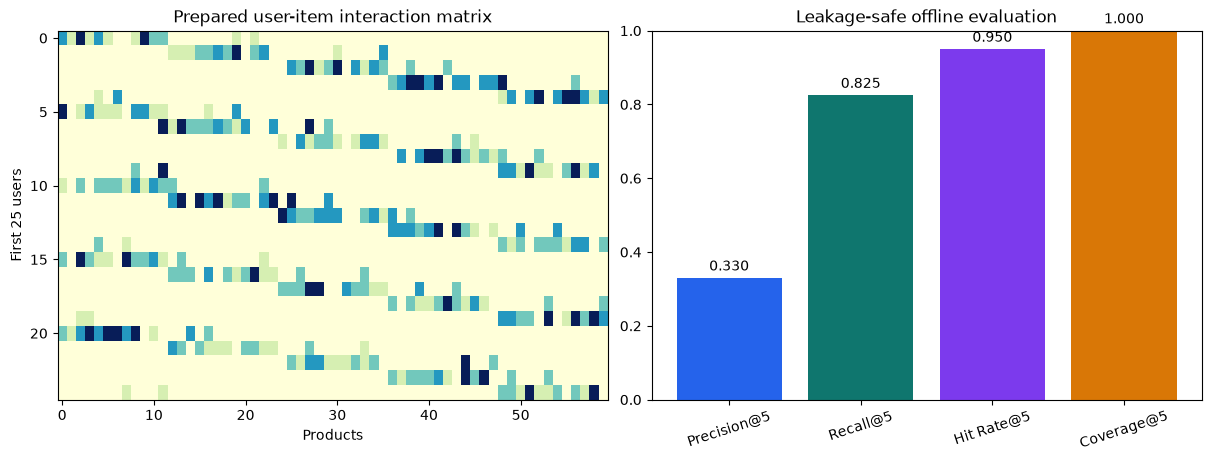

In [4]:

metrics = metadata["metrics"]
metric_names = ["precision_at_k", "recall_at_k", "hit_rate_at_k", "catalogue_coverage_at_k"]
labels = ["Precision@5", "Recall@5", "Hit Rate@5", "Coverage@5"]
values = [metrics[name] for name in metric_names]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), constrained_layout=True)
axes[0].imshow(prepared.matrix[:25], aspect="auto", cmap="YlGnBu")
axes[0].set_title("Prepared user-item interaction matrix")
axes[0].set_xlabel("Products")
axes[0].set_ylabel("First 25 users")
bars = axes[1].bar(labels, values, color=["#2563EB", "#0F766E", "#7C3AED", "#D97706"])
axes[1].set_ylim(0, 1)
axes[1].set_title("Leakage-safe offline evaluation")
axes[1].tick_params(axis="x", rotation=18)
for bar, value in zip(bars, values, strict=True):
    axes[1].text(bar.get_x() + bar.get_width()/2, value + 0.02, f"{value:.3f}", ha="center")
plt.show()



## 3. Architectural patterns

### Pattern 1 - Microservices

The Command Service and Query Service are separate FastAPI applications with
independent ports and deployment commands. Training/write workloads can scale
separately from latency-sensitive recommendation reads.

### Pattern 2 - CQRS

- **Commands:** `POST /commands/interactions` and `POST /commands/train`
- **Queries:** `GET /queries/recommendations` and `GET /queries/model-info`

The write side produces an immutable, versioned model artifact. The read side
never modifies training data and reloads the artifact when its version changes.


### Pattern code: CQRS command/write microservice

```python
"""FastAPI command service: interaction writes and model training."""

from __future__ import annotations

import threading
from datetime import UTC, datetime
from pathlib import Path
from typing import Any
from uuid import uuid4

from fastapi import FastAPI, HTTPException, status

from ecom_ml.api_models import InteractionCommand, TrainCommand
from ecom_ml.config import Settings
from ecom_ml.ml.data import Interaction, append_interaction
from ecom_ml.ml.pipeline import train_pipeline


def create_app(
    *,
    data_path: Path | None = None,
    artifact_dir: Path | None = None,
) -> FastAPI:
    """Build a command service with injectable paths for testing."""
    settings = Settings.from_env()
    resolved_data = data_path or settings.data_path
    resolved_artifacts = artifact_dir or settings.artifact_dir
    training_lock = threading.Lock()
    application = FastAPI(
        title="SEML Recommendation Command Service",
        version="1.0.0",
        description=(
            "CQRS write side: records implicit-feedback commands and trains "
            "the collaborative-filtering read model."
        ),
    )

    @application.get("/health")
    def health() -> dict[str, str]:
        return {"status": "ok", "service": "command-service", "pattern": "CQRS-command"}

    @application.post("/commands/interactions", status_code=status.HTTP_202_ACCEPTED)
    def record_interaction(command: InteractionCommand) -> dict[str, str]:
        interaction = Interaction(
            event_id=f"cmd-{uuid4().hex}",
            timestamp=command.timestamp or datetime.now(UTC).isoformat(timespec="seconds"),
            user_id=command.user_id,
            item_id=command.item_id,
            action=command.action,
        )
        try:
            append_interaction(resolved_data, interaction)
        except ValueError as exc:
            raise HTTPException(status_code=400, detail=str(exc)) from exc
        return {
            "status": "accepted",
            "event_id": interaction.event_id,
            "pattern": "CQRS-command",
        }

    @application.post("/commands/train")
    def train(command: TrainCommand) -> dict[str, Any]:
        if not training_lock.acquire(blocking=False):
            raise HTTPException(status_code=409, detail="training is already running")
        try:
            summary = train_pipeline(
                resolved_data,
                resolved_artifacts,
                k=command.k,
                holdout_per_user=command.holdout_per_user,
            )
            return {
                "status": "trained",
                "pattern": "CQRS-command",
                "summary": summary.as_dict(),
            }
        except (FileNotFoundError, ValueError) as exc:
            raise HTTPException(status_code=400, detail=str(exc)) from exc
        finally:
            training_lock.release()

    return application


app = create_app()

```

### Pattern code: CQRS query/read microservice

```python
"""FastAPI query service backed by the latest immutable model artifact."""

from __future__ import annotations

import threading
from pathlib import Path
from typing import Any

from fastapi import FastAPI, HTTPException, Query

from ecom_ml.api_models import RecommendationResponse
from ecom_ml.config import Settings
from ecom_ml.ml.artifact import METADATA_FILENAME, load_artifact
from ecom_ml.ml.model import CollaborativeFilteringModel


class ModelRepository:
    """Thread-safe, mtime-aware cache of the CQRS read model."""

    def __init__(self, artifact_dir: Path) -> None:
        self._artifact_dir = artifact_dir
        self._lock = threading.RLock()
        self._model: CollaborativeFilteringModel | None = None
        self._metadata: dict[str, Any] | None = None
        self._metadata_mtime_ns = -1

    def get(self) -> tuple[CollaborativeFilteringModel, dict[str, Any]]:
        metadata_path = self._artifact_dir / METADATA_FILENAME
        if not metadata_path.exists():
            raise FileNotFoundError("no trained model; run the training command first")
        current_mtime = metadata_path.stat().st_mtime_ns
        with self._lock:
            if self._model is None or current_mtime != self._metadata_mtime_ns:
                self._model, self._metadata = load_artifact(self._artifact_dir)
                self._metadata_mtime_ns = current_mtime
            assert self._metadata is not None
            return self._model, dict(self._metadata)


def create_app(*, artifact_dir: Path | None = None) -> FastAPI:
    """Build a query service with an injectable artifact location."""
    settings = Settings.from_env()
    repository = ModelRepository(artifact_dir or settings.artifact_dir)
    application = FastAPI(
        title="SEML Recommendation Query Service",
        version="1.0.0",
        description=(
            "CQRS read side: independently serves low-latency recommendations "
            "from a versioned collaborative-filtering model."
        ),
    )

    @application.get("/health")
    def health() -> dict[str, str]:
        try:
            model, _ = repository.get()
        except (FileNotFoundError, ValueError):
            return {"status": "not_ready", "service": "query-service", "pattern": "CQRS-query"}
        return {
            "status": "ok",
            "service": "query-service",
            "pattern": "CQRS-query",
            "model_version": model.version,
        }

    @application.get("/queries/model-info")
    def model_info() -> dict[str, Any]:
        try:
            _, metadata = repository.get()
        except (FileNotFoundError, ValueError) as exc:
            raise HTTPException(status_code=503, detail=str(exc)) from exc
        return {"pattern": "CQRS-query", **metadata}

    @application.get("/queries/recommendations", response_model=RecommendationResponse)
    def recommendations(
        user_id: str = Query(min_length=1),
        k: int = Query(default=5, ge=1, le=20),
    ) -> RecommendationResponse:
        try:
            model, _ = repository.get()
            ranked = model.recommend(user_id, k)
        except (FileNotFoundError, ValueError) as exc:
            raise HTTPException(status_code=503, detail=str(exc)) from exc
        except KeyError as exc:
            raise HTTPException(status_code=404, detail=str(exc)) from exc
        return RecommendationResponse(
            user_id=user_id,
            model_version=model.version,
            strategy="item-based-collaborative-filtering",
            recommendations=[
                {"item_id": recommendation.item_id, "score": recommendation.score}
                for recommendation in ranked
            ],
        )

    return application


app = create_app()

```


## 4. GR4ML views and cross-view traceability

The diagrams follow the notation taught in Session 3:

- **Business View:** stick-figure Actor, oval Business Goal, D-marked Decision
  Goal, Q-marked Question Goal, traffic-light Indicator, and structured Insight.
- **Analytics Design View:** oval Analytics Goal, hexagonal Algorithm,
  cloud-shaped Softgoal, traffic-light Indicator, and the Performs, Evaluates,
  Generates, Association, and Influence links.
- **Data Preparation View:** structured Entity, rectangular Operator,
  folded-corner Note, solid Data Flow, dashed Input/Output, and Relationship.

The trace across the views is:

`Prepared User-Item Matrix` **is required for** the Prediction and Ranking
Analytics Goal -> the goal **generates** the Top-5 Recommendation Insight ->
the insight **answers** the Question Goal -> the answer supports the product
Decision Goal -> the decision contributes to the revenue Business Goal.


GR4ML Business View


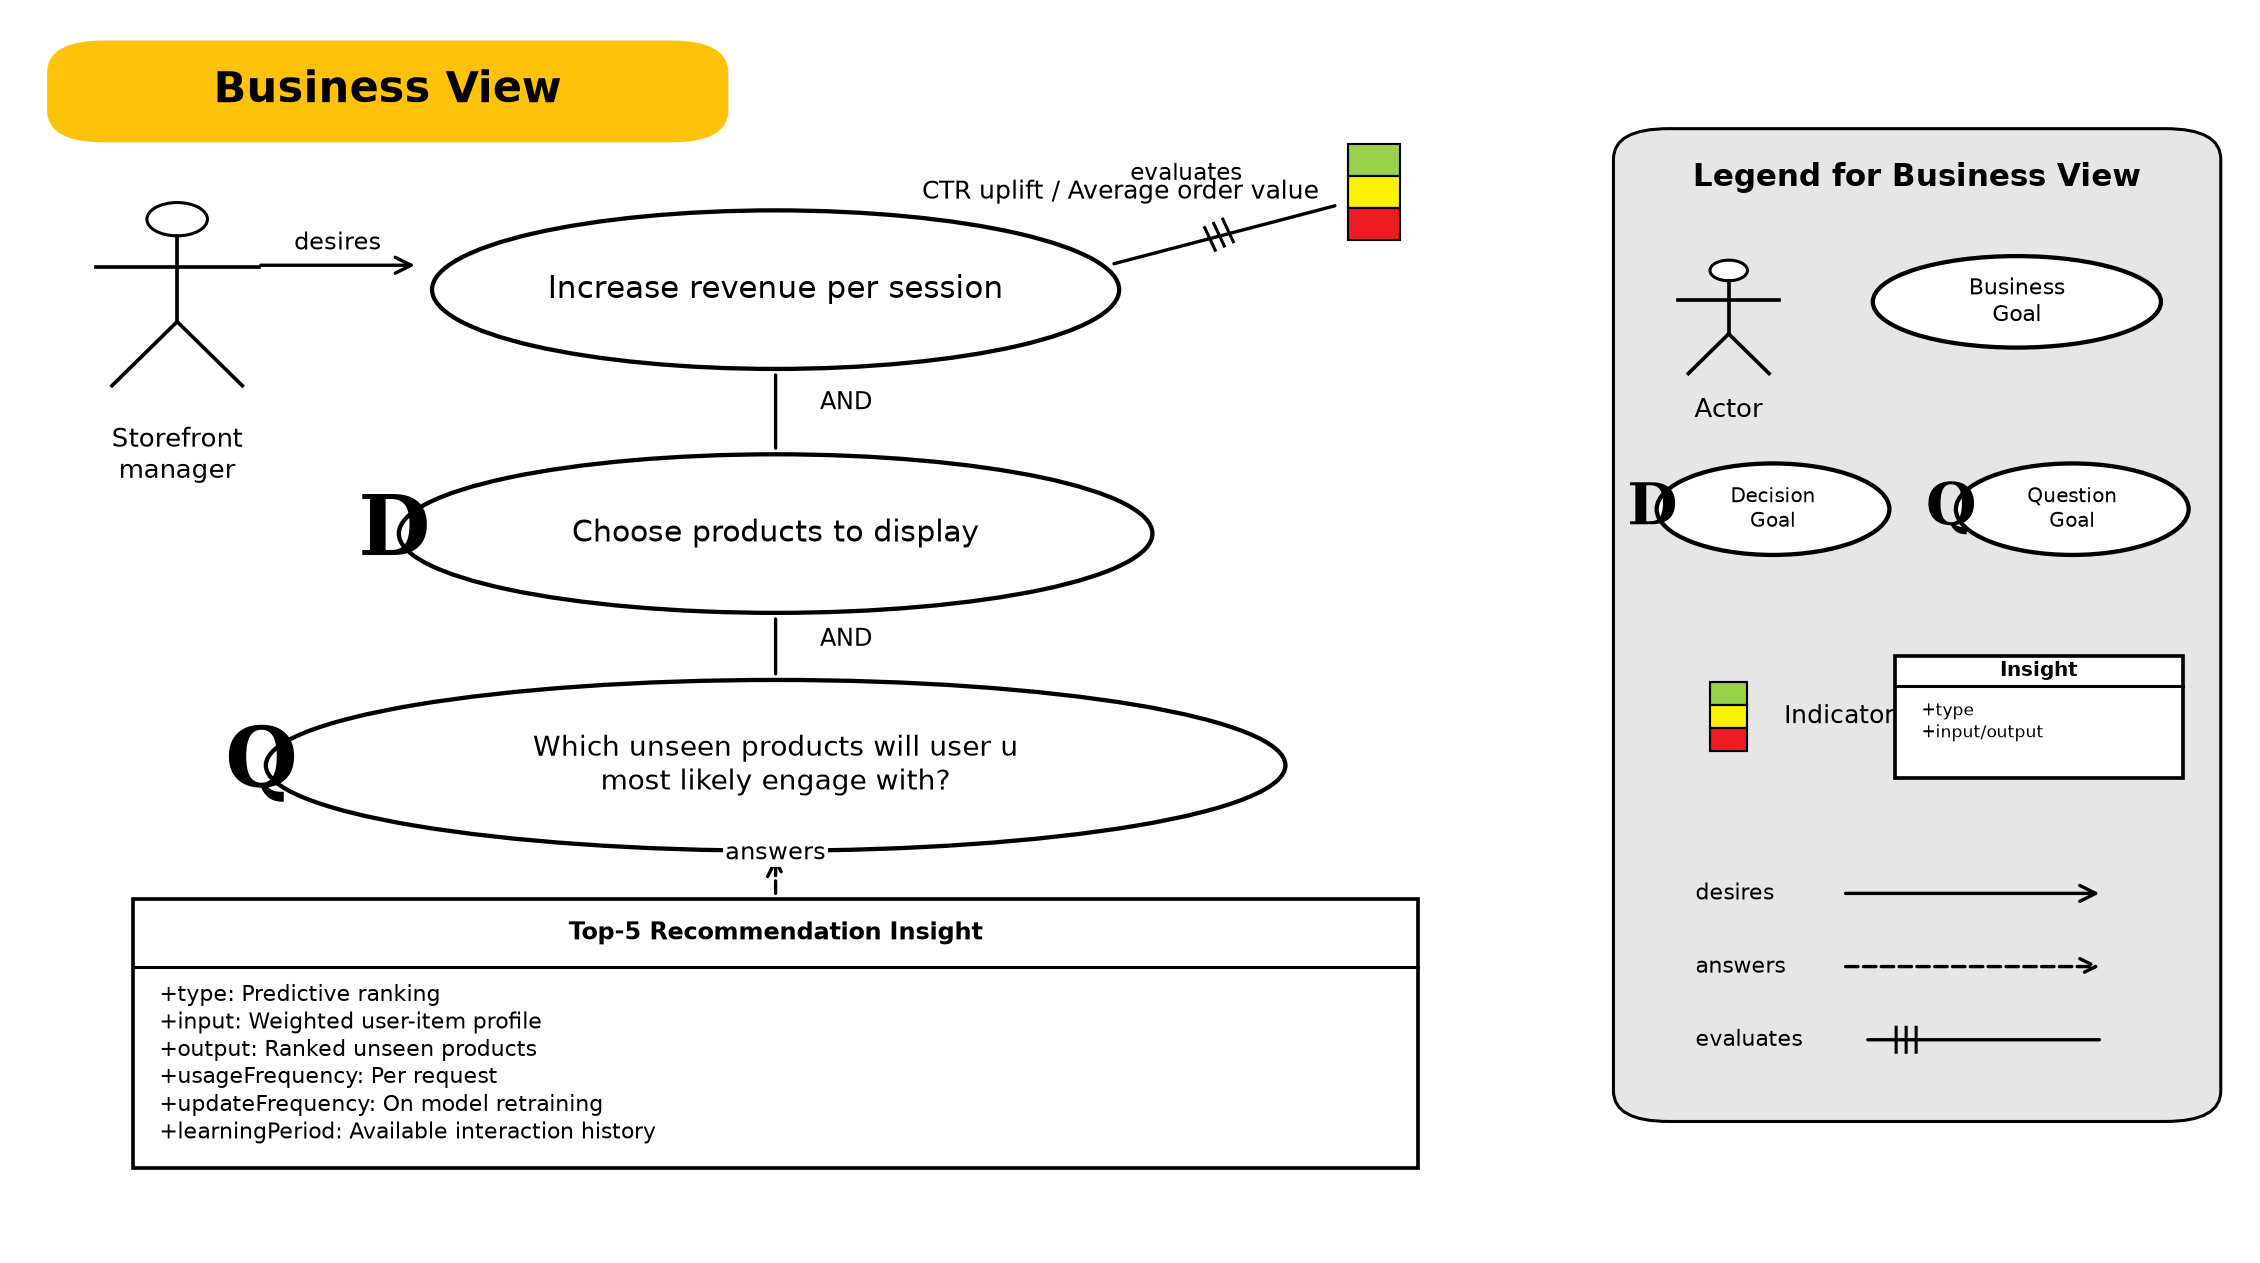

GR4ML Analytics Design View


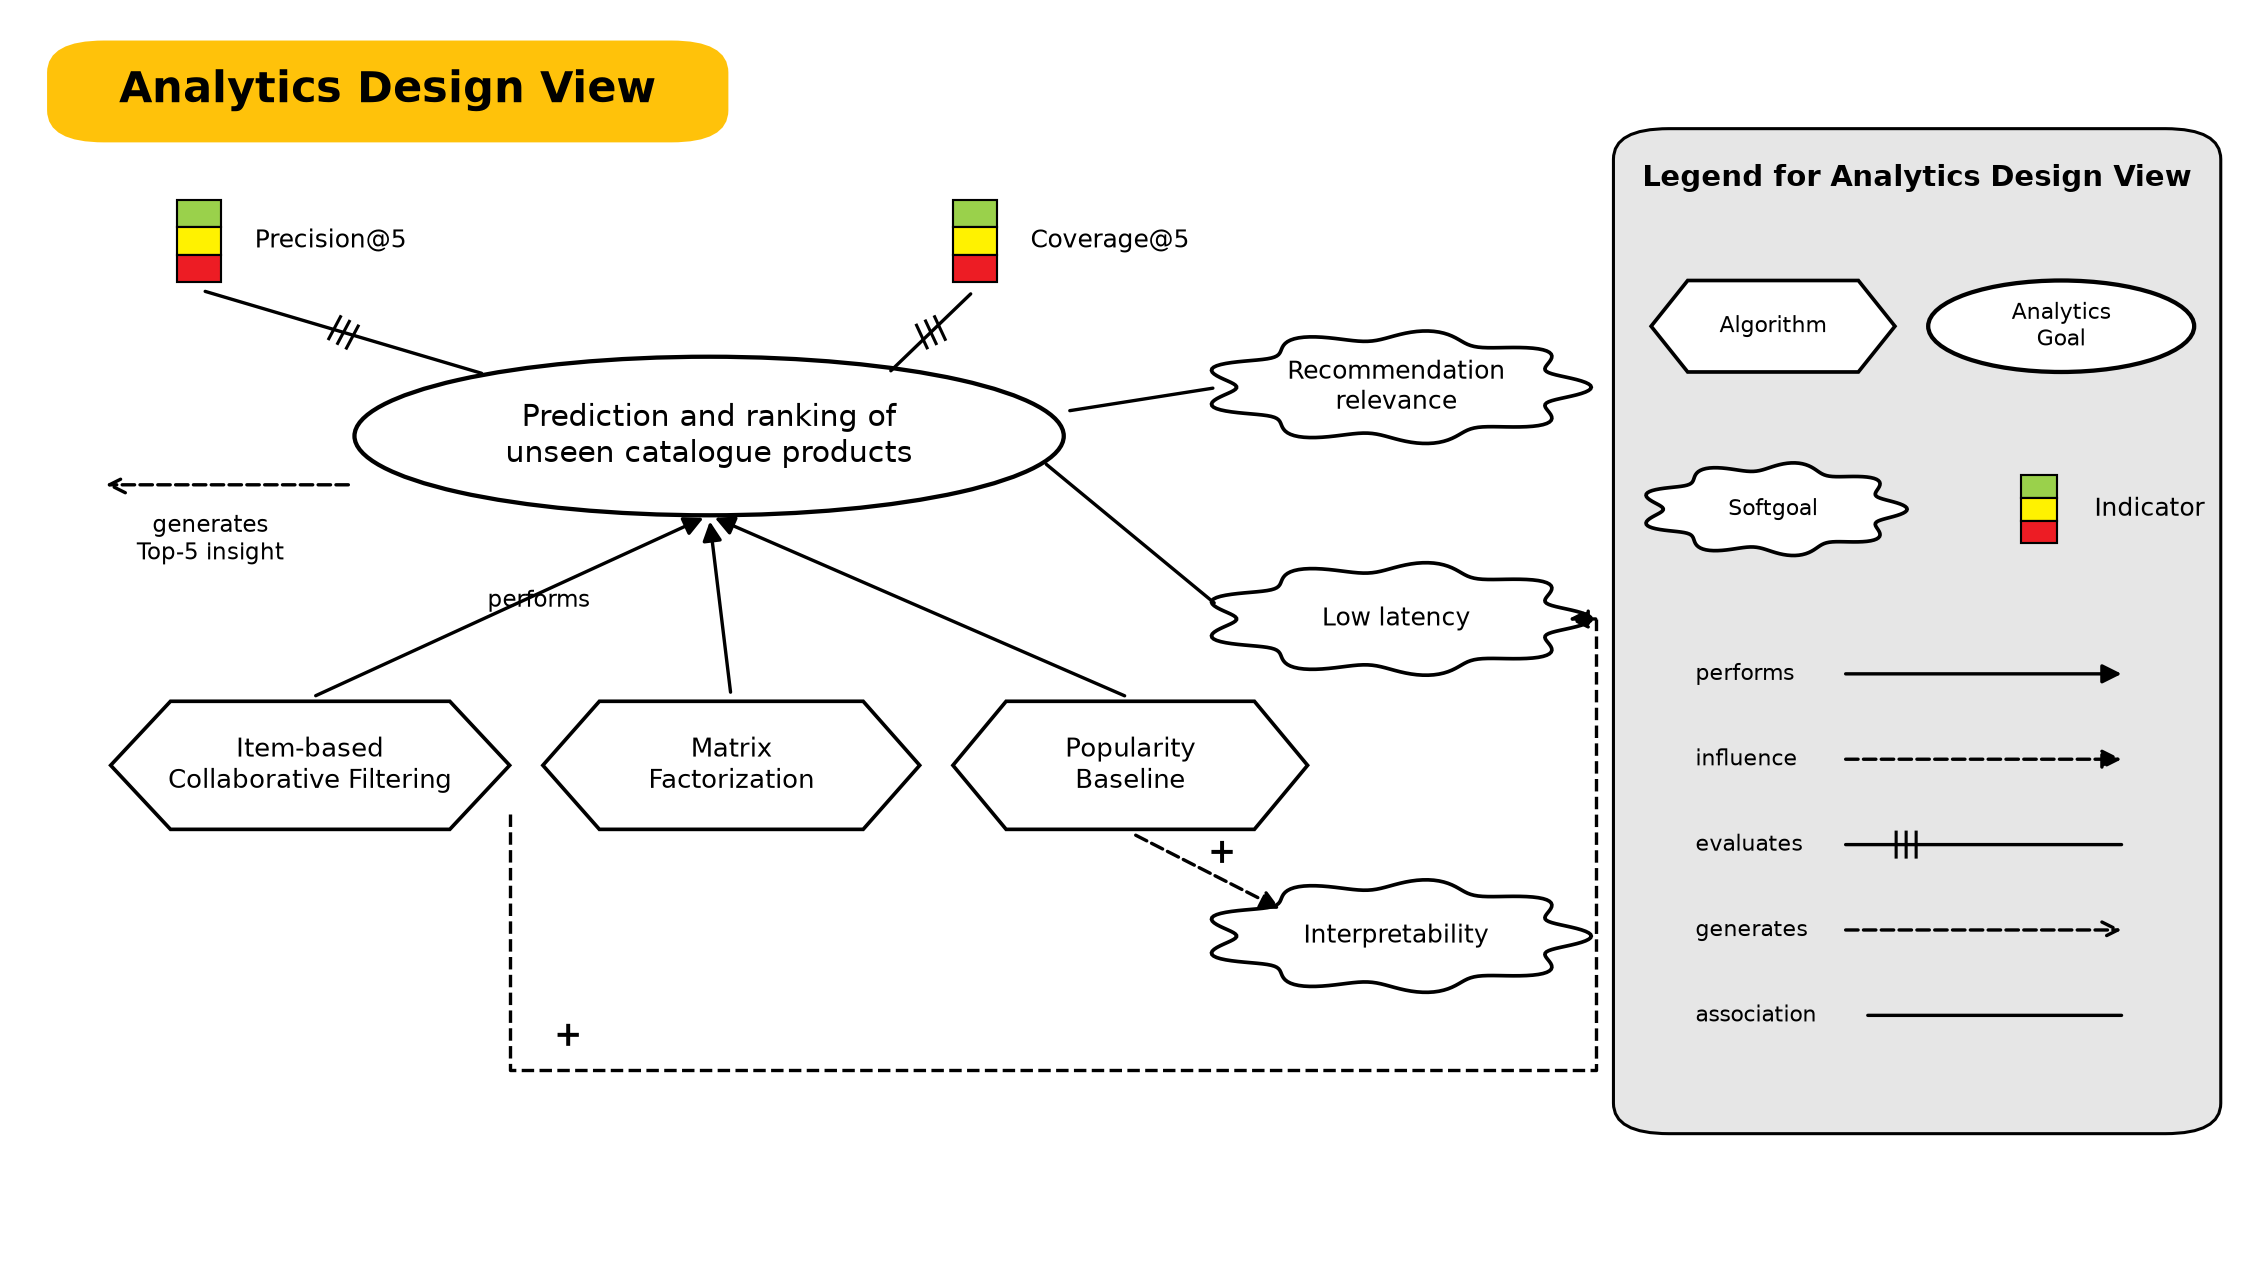

GR4ML Data Preparation View


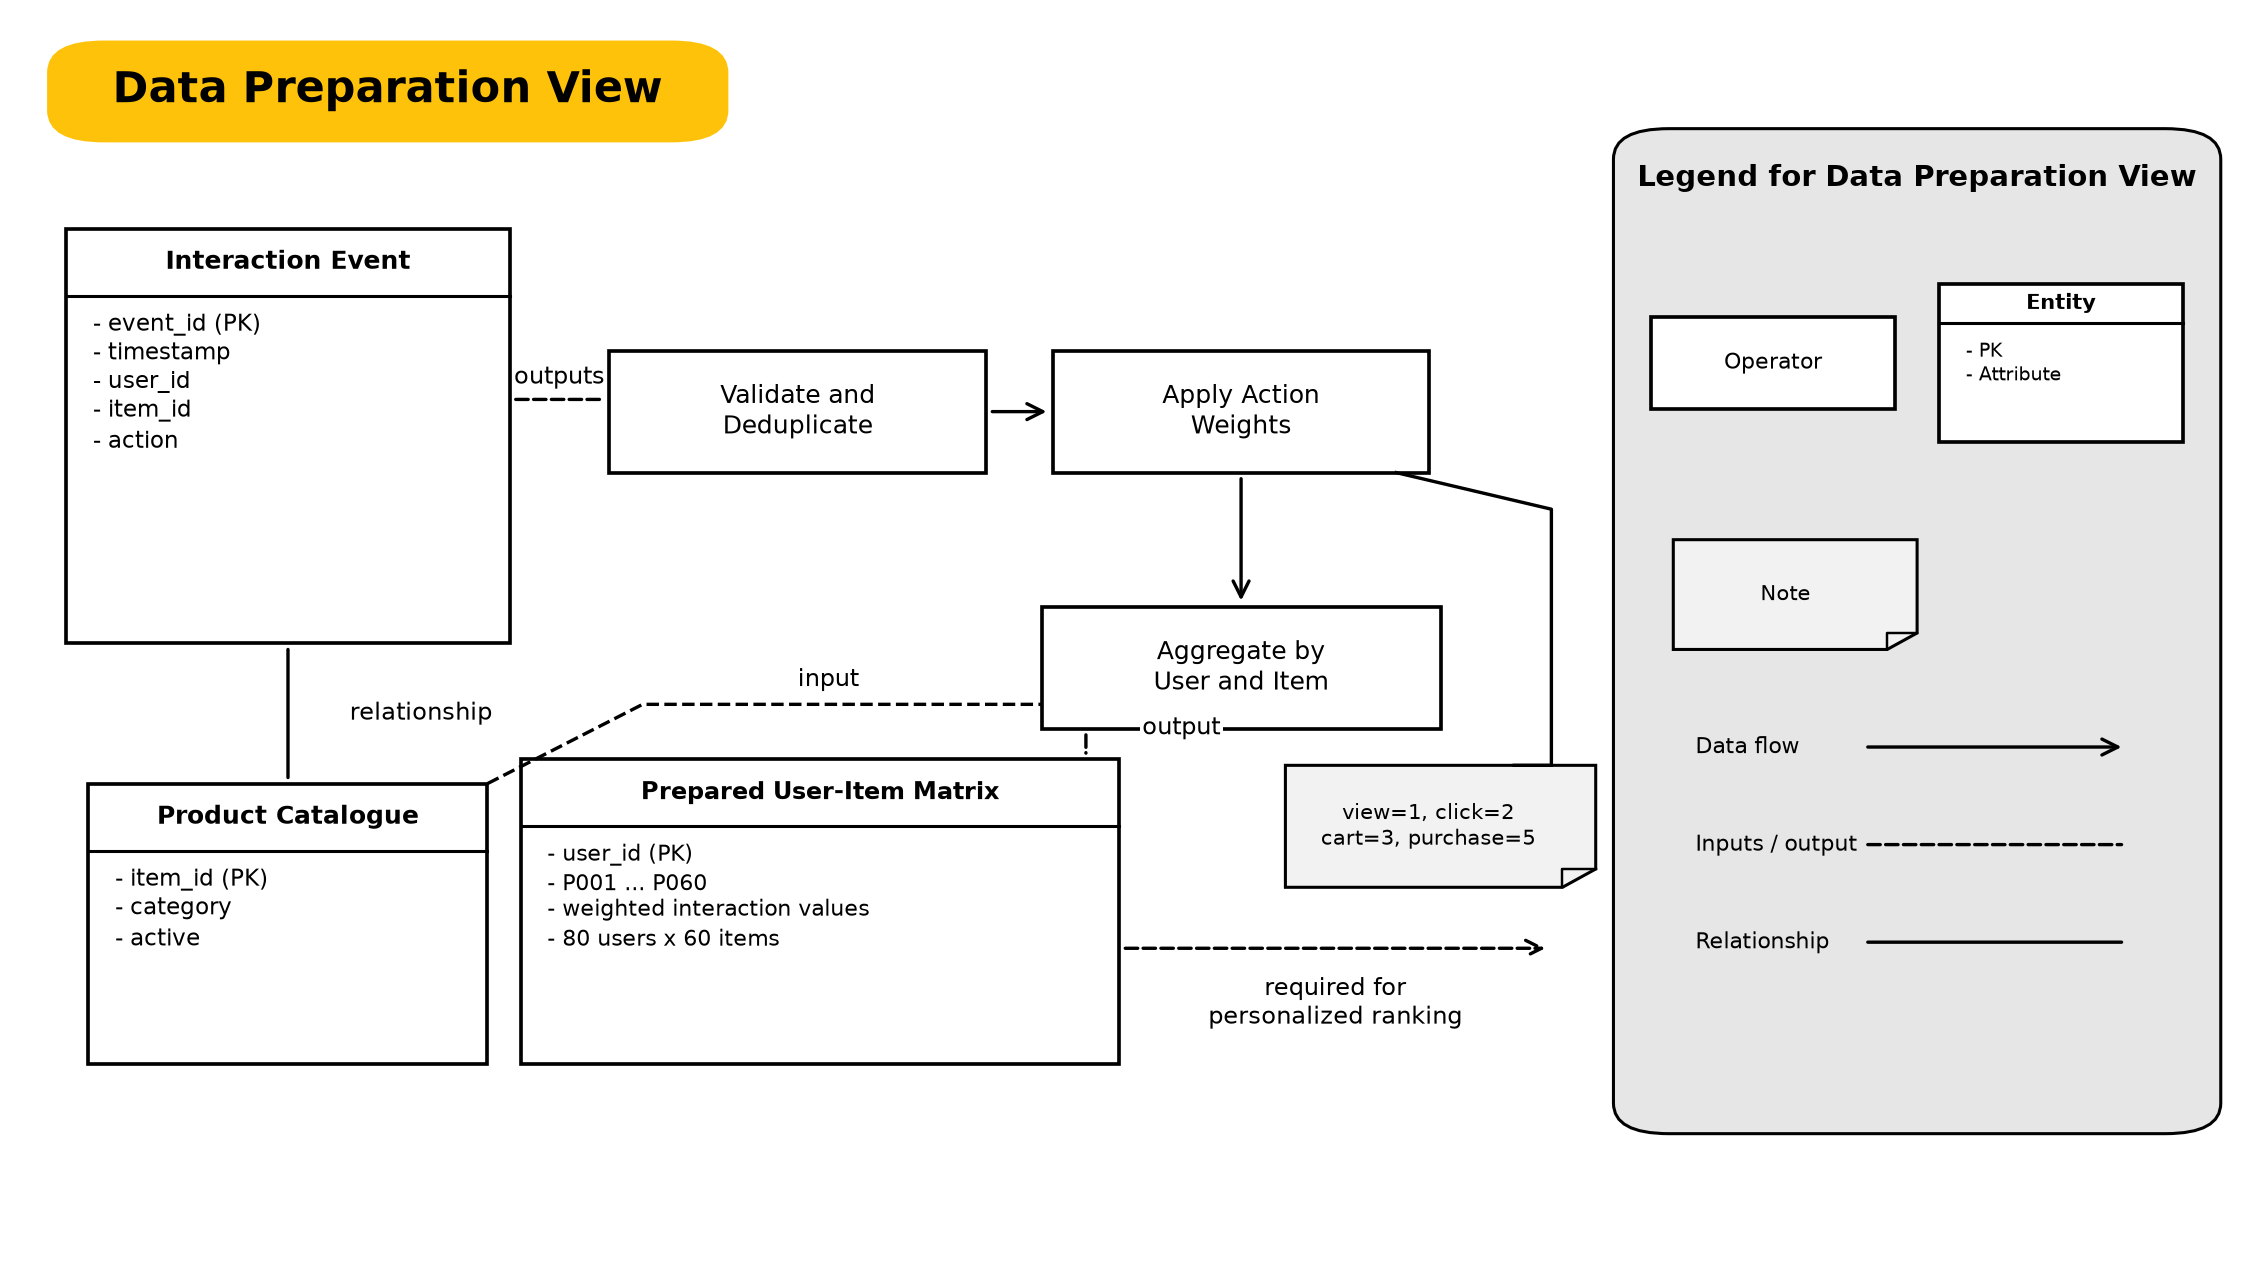

System Architecture


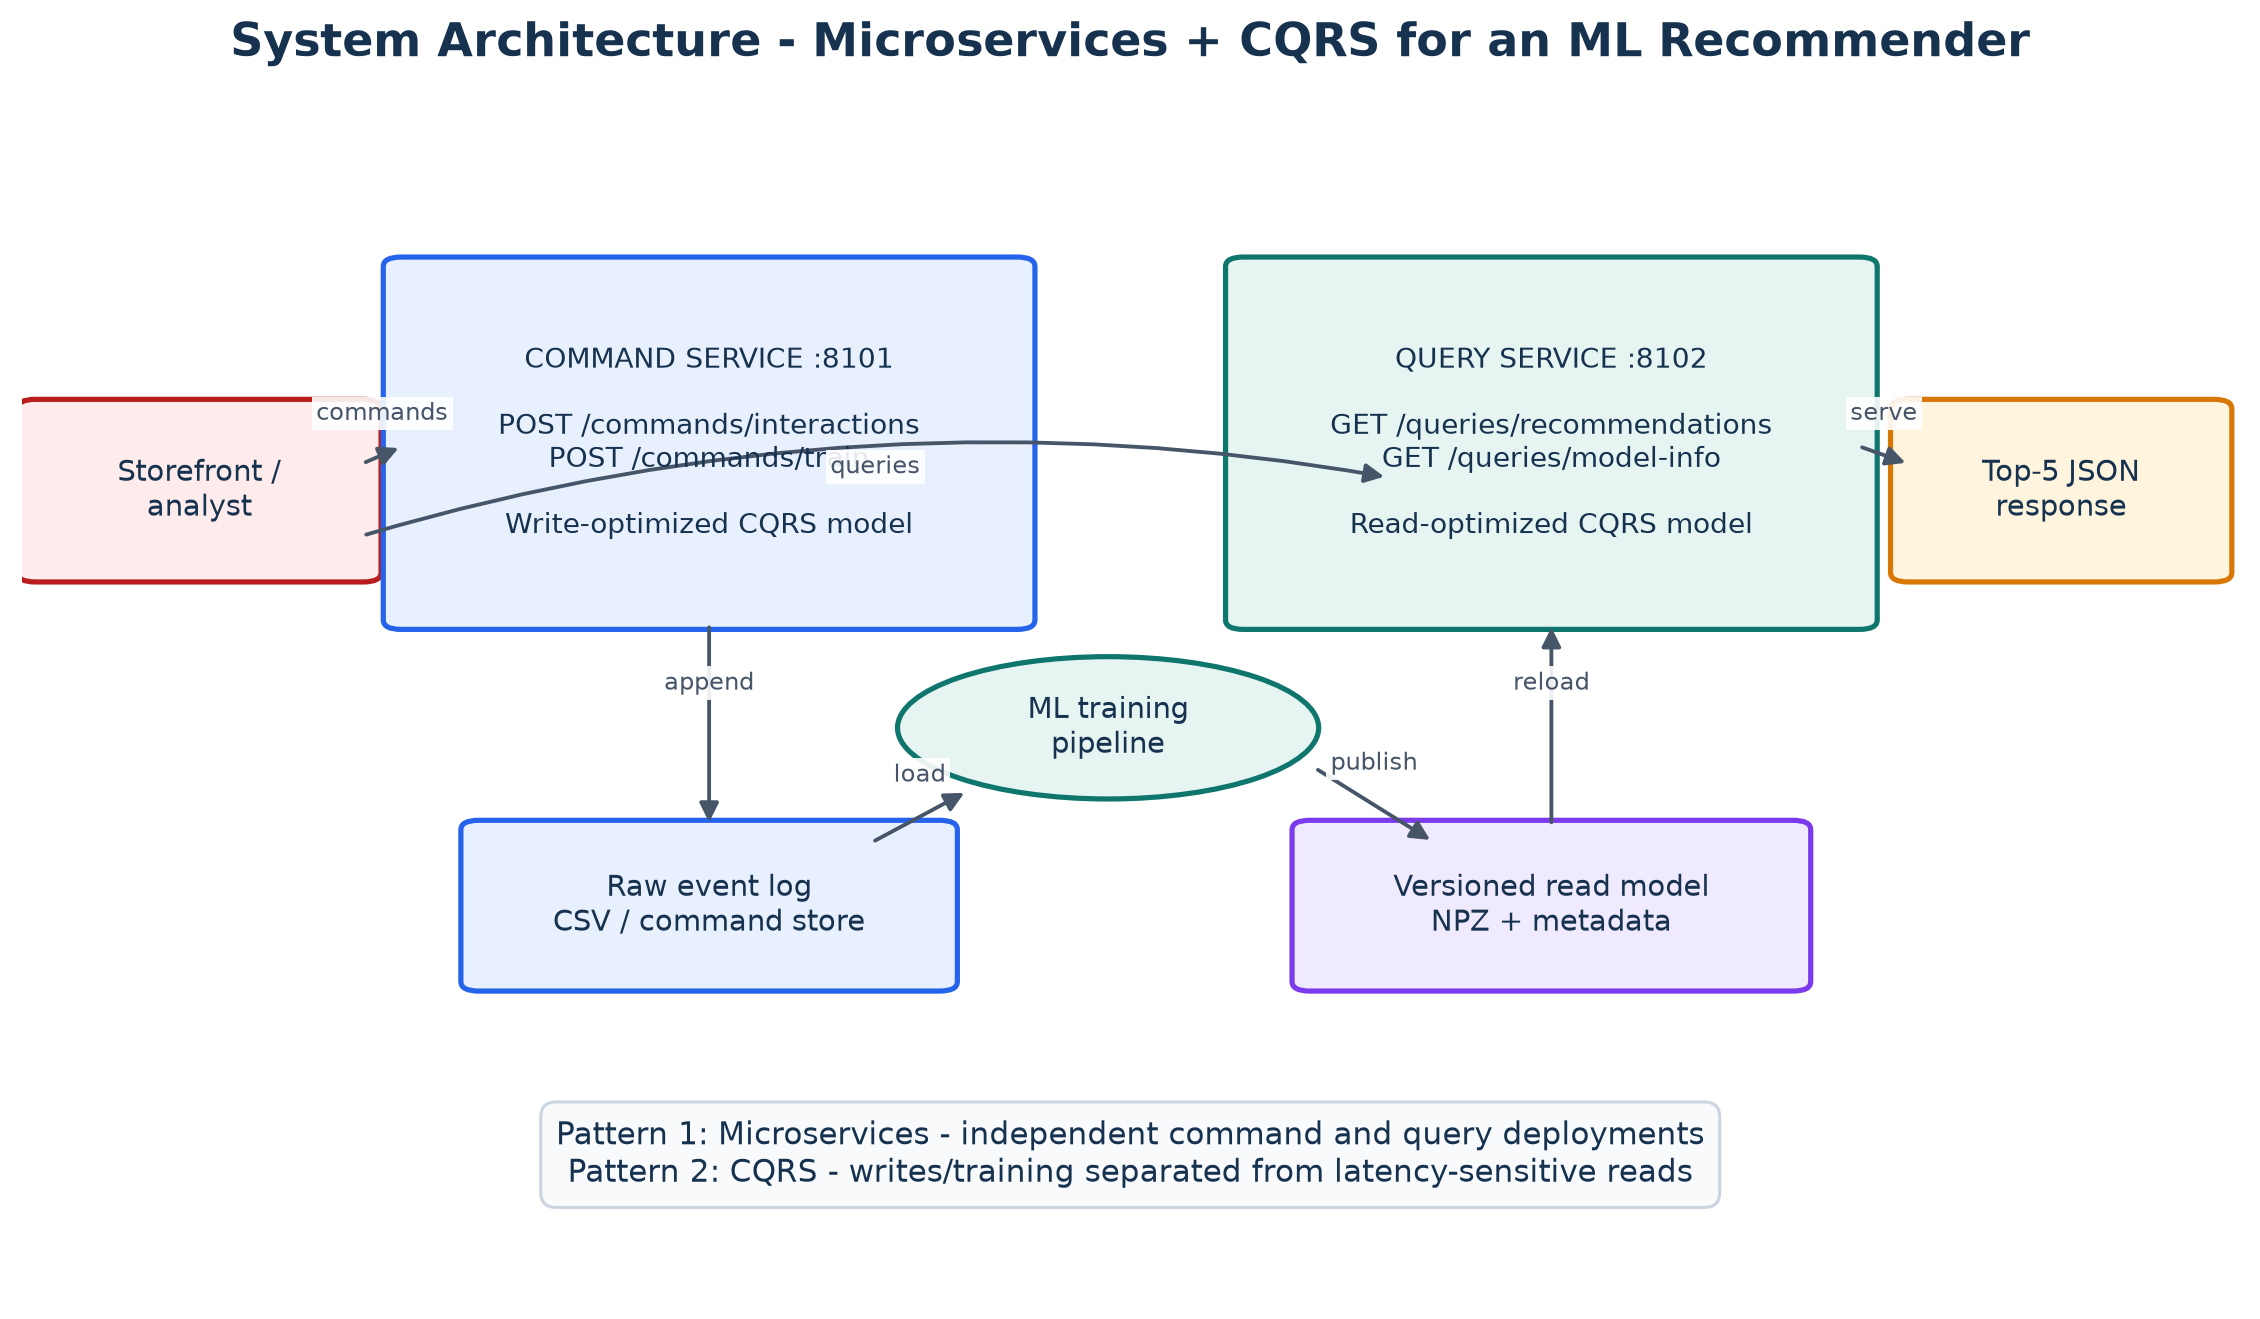

Executed application evidence


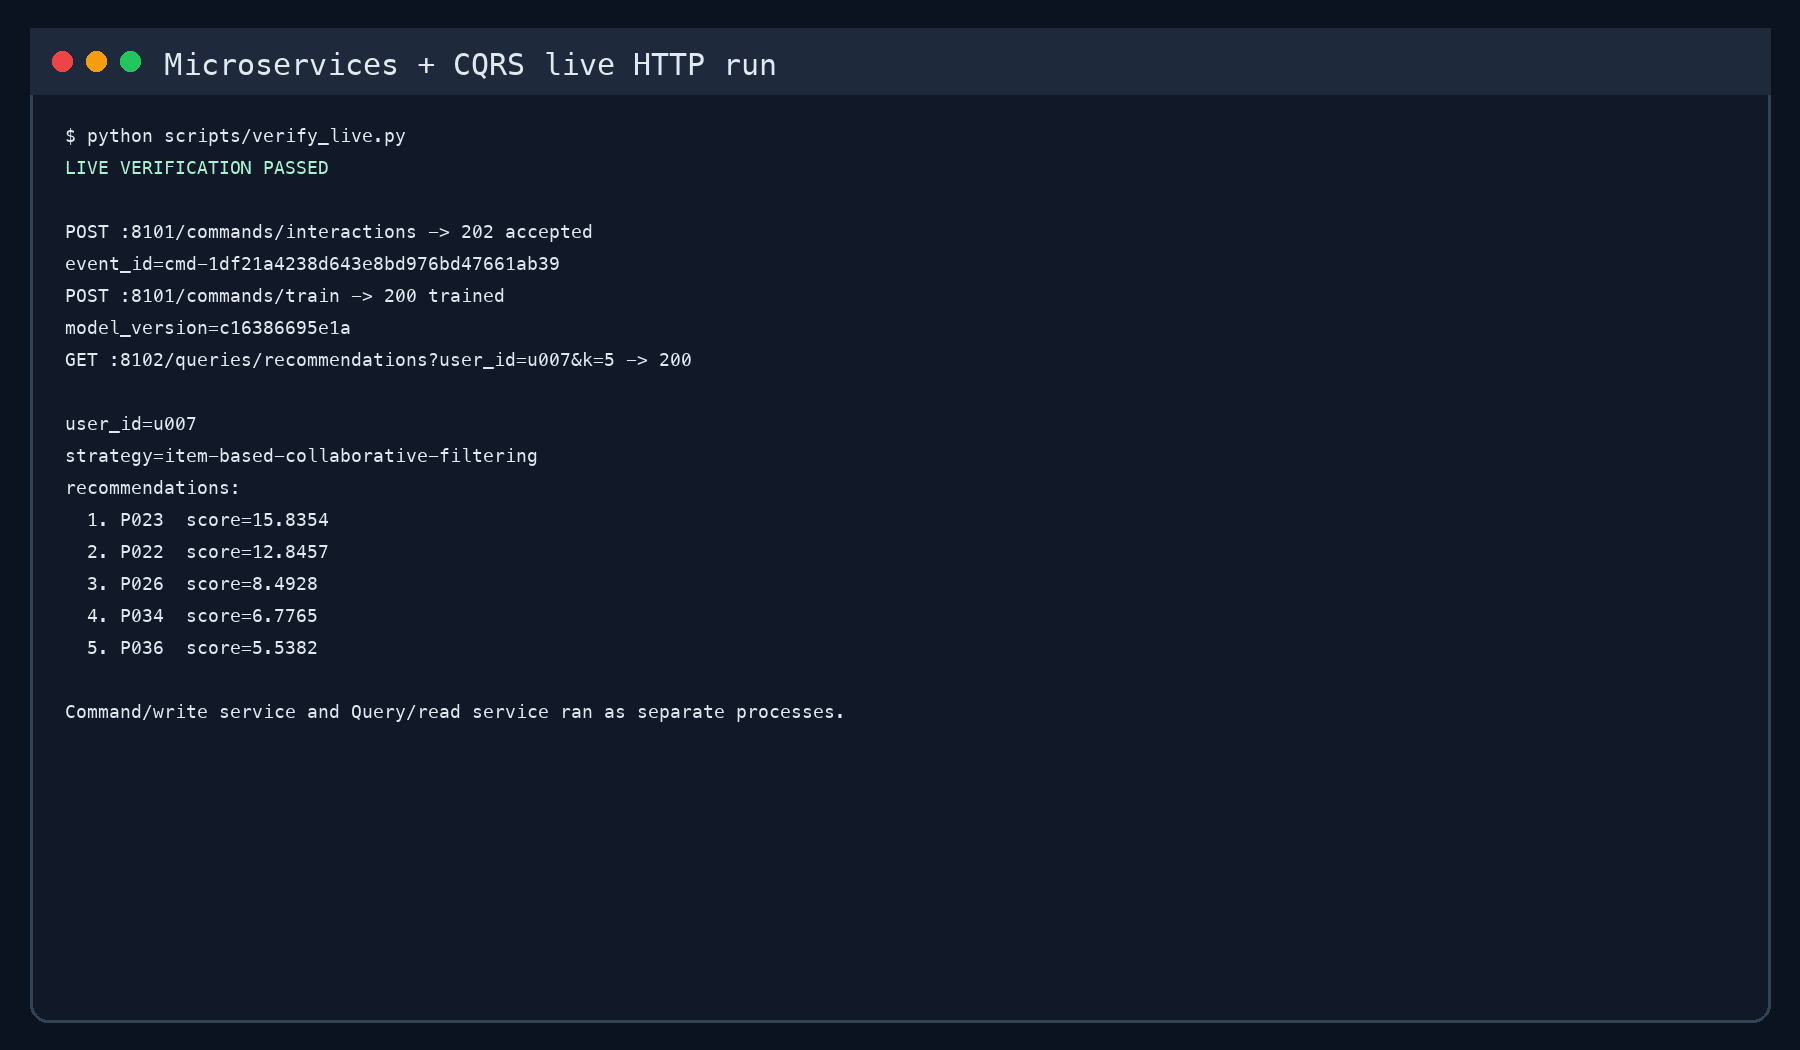

In [5]:

from IPython.display import Image, display

visuals = [
    ("GR4ML Business View", ROOT / "evidence" / "gr4ml_business_view.png"),
    ("GR4ML Analytics Design View", ROOT / "evidence" / "gr4ml_analytics_design_view.png"),
    ("GR4ML Data Preparation View", ROOT / "evidence" / "gr4ml_data_preparation_view.png"),
    ("System Architecture", ROOT / "evidence" / "system_architecture.png"),
    ("Executed application evidence", ROOT / "evidence" / "live_execution.png"),
]
for title, path in visuals:
    print(title)
    if path.exists():
        display(Image(filename=str(path)))
    else:
        print("Generate with: python tools/generate_assets.py")



## 5. Result

The execution above proves that the dataset was prepared, the model was
trained and evaluated, a versioned artifact was saved and loaded, and unseen
items were ranked for a real user. The attached report provides the complete
requirements formulation, three GR4ML views, quality requirements, architecture
justification, screenshots, limitations, and references.
